## **Linear Regression from Scratch: **

Implementation of Gradient Descent & Quadratic Cost

Linear Regression: The "Hard Way"In this lab, we implement Linear Regression without using libraries like Scikit-Learn. We will derive the gradients of the Quadratic Cost Function and update our parameters manually.1. The HypothesisFor a single feature $x$, our model is:$$\hat{y} = mx + b$$2. The Quadratic Cost Function (Mean Squared Error)We measure the error $J$ as the average of the squared differences:$$J(m, b) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$3. The Gradients (Partial Derivatives)To minimize $J$, we find how the cost changes with respect to $m$ and $b$:$$\frac{\partial J}{\partial m} = \frac{1}{n} \sum (mx_i + b - y_i) \cdot x_i$$


$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum (mx_i + b - y_i)$$

## **Lab Observations**

Convergence: Observe the "Cost Convergence" plot. Why does the cost drop rapidly at first and then flatten out? (Hint: The gradient gets smaller as we approach the minimum).

Learning Rate Sensitivity: If you change lr to 2.0, the cost will explode. This is because the "step" is so large that the optimizer overshoots the minimum and climbs the other side of the "bowl."

From-Scratch vs. Libraries: In a library like PyTorch, the error * X step is handled automatically via AutoGrad, but the underlying math remains exactly the same as what you wrote above.

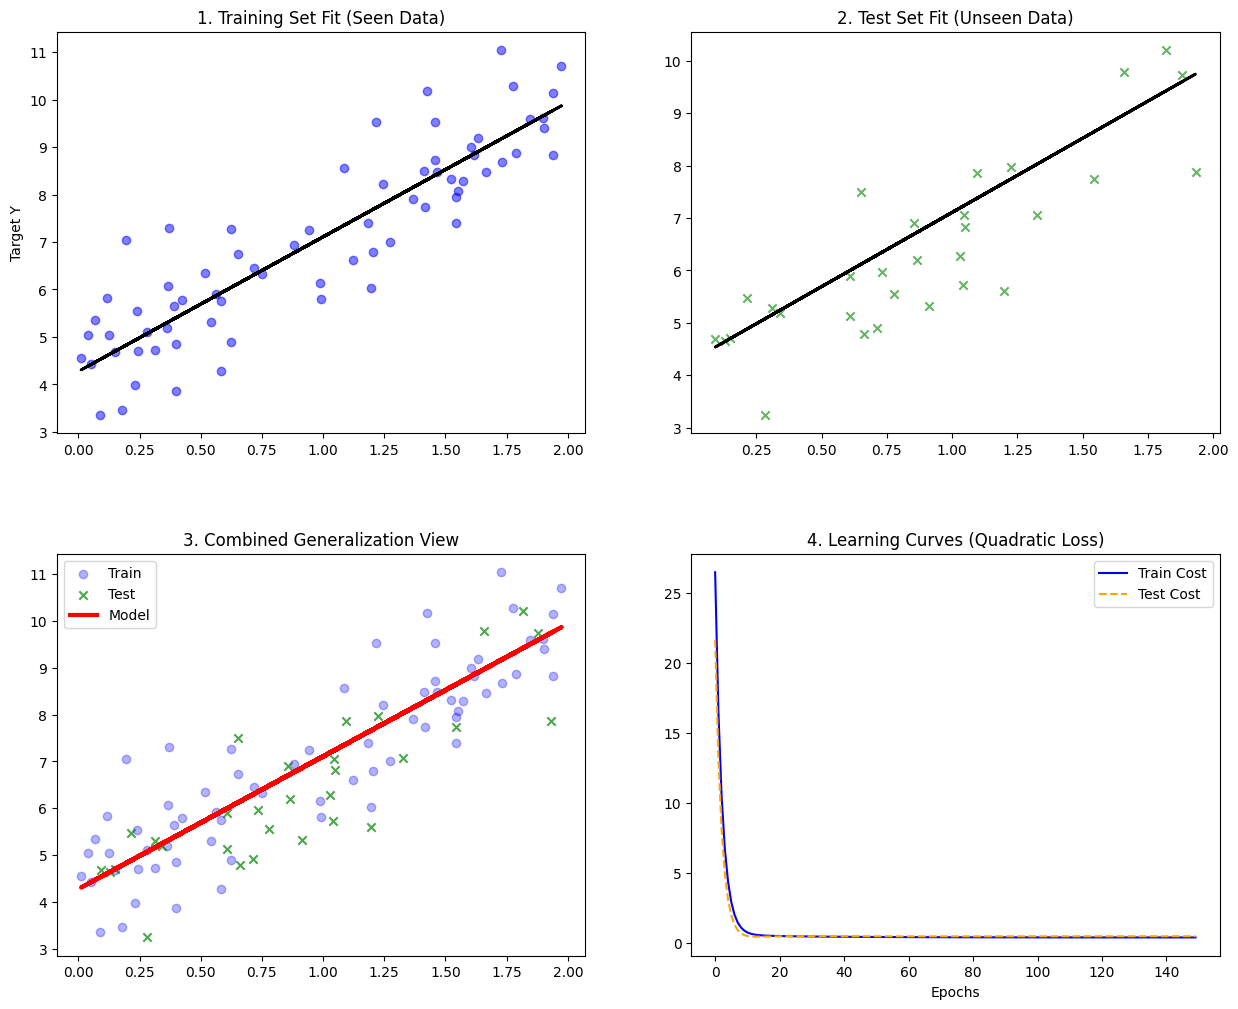

Final Weights: m=2.834, b=4.274
Train MSE: 0.3852 | Test MSE: 0.4716


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DATA GENERATION & MANUAL SPLIT (70/30) ---
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

indices = np.arange(100)
np.random.shuffle(indices)
train_idx, test_idx = indices[:70], indices[70:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# --- 2. GRADIENT DESCENT FROM SCRATCH ---
m, b = 0.0, 0.0
lr = 0.1
epochs = 150
n_train, n_test = float(len(X_train)), float(len(X_test))

train_costs, test_costs = [], []

for i in range(epochs):
    # Forward Pass & Cost Calculation
    y_train_pred = m * X_train + b
    y_test_pred = m * X_test + b

    train_costs.append((1 / (2 * n_train)) * np.sum((y_train_pred - y_train)**2))
    test_costs.append((1 / (2 * n_test)) * np.sum((y_test_pred - y_test)**2))

    # Gradient Calculation (Training Data ONLY)
    dm = (1 / n_train) * np.sum((y_train_pred - y_train) * X_train)
    db = (1 / n_train) * np.sum(y_train_pred - y_train)

    # Update Parameters
    m -= lr * dm
    b -= lr * db

# --- 3. COMPREHENSIVE VISUALIZATION ---
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3)

# Plot A: Training Set Only
axs[0, 0].scatter(X_train, y_train, color='blue', alpha=0.5)
axs[0, 0].plot(X_train, m * X_train + b, color='black', lw=2)
axs[0, 0].set_title("1. Training Set Fit (Seen Data)")
axs[0, 0].set_ylabel("Target Y")

# Plot B: Test Set Only
axs[0, 1].scatter(X_test, y_test, color='green', alpha=0.6, marker='x')
axs[0, 1].plot(X_test, m * X_test + b, color='black', lw=2)
axs[0, 1].set_title("2. Test Set Fit (Unseen Data)")

# Plot C: Combined Visualization
axs[1, 0].scatter(X_train, y_train, color='blue', alpha=0.3, label="Train")
axs[1, 0].scatter(X_test, y_test, color='green', alpha=0.7, marker='x', label="Test")
axs[1, 0].plot(X, m * X + b, color='red', lw=3, label="Model")
axs[1, 0].set_title("3. Combined Generalization View")
axs[1, 0].legend()

# Plot D: Learning Curves (Cost vs Epochs)
axs[1, 1].plot(range(epochs), train_costs, color='blue', label="Train Cost")
axs[1, 1].plot(range(epochs), test_costs, color='orange', linestyle='--', label="Test Cost")
axs[1, 1].set_title("4. Learning Curves (Quadratic Loss)")
axs[1, 1].set_xlabel("Epochs")
axs[1, 1].legend()

plt.show()

print(f"Final Weights: m={m:.3f}, b={b:.3f}")
print(f"Train MSE: {train_costs[-1]:.4f} | Test MSE: {test_costs[-1]:.4f}")

## **Multivariate Linear Regression:**

Vectorized ApproachWhen we have multiple input features ($x_1, x_2, x_3$), our hypothesis becomes:$$\hat{y} = w_1x_1 + w_2x_2 + w_3x_3 + b$$1. Vector RepresentationTo make this computationally efficient, we represent our parameters as a vector $\mathbf{w}$ and our features as a matrix $\mathbf{X}$.$$\hat{y} = \mathbf{X} \cdot \mathbf{w} + b$$2. Quadratic Cost Function (Vectorized MSE)The cost function remains the same, but we calculate it using the dot product:$$J(\mathbf{w}, b) = \frac{1}{2n} \|\mathbf{Xw} + b - \mathbf{y}\|^2$$3. Vectorized GradientsThe derivatives for all weights can be calculated simultaneously:$$\nabla_{\mathbf{w}} J = \frac{1}{n} \mathbf{X}^T (\mathbf{Xw} + b - \mathbf{y})$$$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum (\mathbf{Xw} + b - \mathbf{y})$$

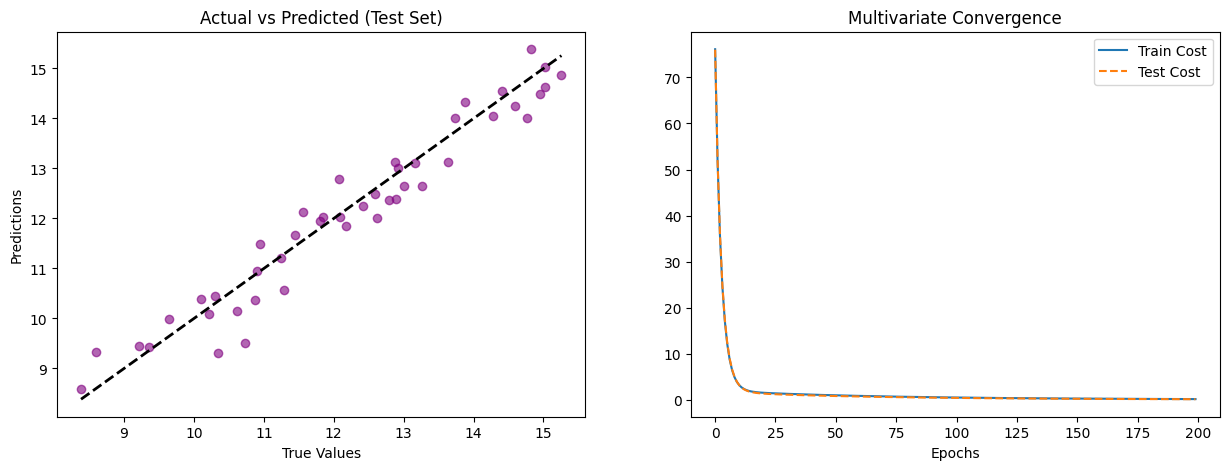

Final Weights:
[[ 2.64532449]
 [ 5.16903892]
 [-1.5348073 ]]
Final Bias: 8.8364


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DATA GENERATION (3 Features) ---
np.random.seed(42)
n_samples = 150
X = np.random.rand(n_samples, 3) # 3 Features
# Target: y = 2x1 + 5x2 - 3x3 + 10 + noise
true_w = np.array([[2], [5], [-3]])
true_b = 10
y = X @ true_w + true_b + np.random.randn(n_samples, 1) * 0.1

# Shuffle and Split (70/30)
indices = np.arange(n_samples)
np.random.shuffle(indices)
train_split = int(0.7 * n_samples)

X_train, y_train = X[indices[:train_split]], y[indices[:train_split]]
X_test, y_test = X[indices[train_split:]], y[indices[train_split:]]

# --- 2. INITIALIZATION ---
w = np.zeros((3, 1)) # Weights for 3 features
b = 0.0              # Scalar Bias
lr = 0.1
epochs = 200
n_train, n_test = float(len(X_train)), float(len(X_test))

train_costs, test_costs = [], []

# --- 3. VECTORIZED GRADIENT DESCENT ---
for i in range(epochs):
    # Forward Pass
    y_train_pred = X_train @ w + b
    y_test_pred = X_test @ w + b

    # Compute Cost
    train_costs.append((1/(2*n_train)) * np.sum((y_train_pred - y_train)**2))
    test_costs.append((1/(2*n_test)) * np.sum((y_test_pred - y_test)**2))

    # Backward Pass (Vectorized Gradient)
    error = y_train_pred - y_train
    dw = (1/n_train) * (X_train.T @ error)
    db = (1/n_train) * np.sum(error)

    # Update
    w -= lr * dw
    b -= lr * db

# --- 4. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Prediction vs Actual (Test Set)
ax1.scatter(y_test, y_test_pred, color='purple', alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax1.set_title("Actual vs Predicted (Test Set)")
ax1.set_xlabel("True Values")
ax1.set_ylabel("Predictions")

# Plot 2: Multivariate Learning Curves
ax2.plot(range(epochs), train_costs, label="Train Cost")
ax2.plot(range(epochs), test_costs, label="Test Cost", linestyle='--')
ax2.set_title("Multivariate Convergence")
ax2.set_xlabel("Epochs")
ax2.legend()

plt.show()

print(f"Final Weights:\n{w}")
print(f"Final Bias: {b:.4f}")

## **Understanding the Multivariate Results**

The "Actual vs Predicted" Plot: Since we can't easily visualize 4D space (3 features + 1 output), we use a Prediction-Actual Correlation Plot. If the points fall on the 45-degree dashed line, the model is perfectly predicting all three features combined.

The Transpose ($\mathbf{X}^T$): In the gradient calculation X_train.T @ error, why do we transpose $X$?

Answer: To align the dimensions. $X$ is $(n \times 3)$, and error is $(n \times 1)$. To get a $(3 \times 1)$ weight update, we must multiply $(3 \times n)$ by $(n \times 1)$.

Feature Scaling: Notice our features were in the same range (0 to 1). If $x_1$ was "House Price" (thousands) and $x_2$ was "Number of Bedrooms" (1–5), Gradient Descent would struggle to converge. This is a great lead-in to Normalization/Standardization.

## **Real World Example - Multivariate Linear Regression:**

Feature Scaling & VectorizationIn real-world datasets, features like Square Footage (thousands) and Distance (units) have different scales. We use Standardization (Z-score) to ensure Gradient Descent converges efficiently.1. The Model$$\hat{y} = \mathbf{X} \mathbf{w} + b$$Where $\mathbf{X}$ is a matrix of shape $(n \times 3)$ and $\mathbf{w}$ is a weight vector of shape $(3 \times 1)$.2. The Objective Function (Quadratic Cost)$$J(\mathbf{w}, b) = \frac{1}{2n} \sum (\hat{y} - y)^2$$3. Gradient Calculation$$\nabla_{\mathbf{w}} J = \frac{1}{n} \mathbf{X}^T (\hat{y} - y)$$

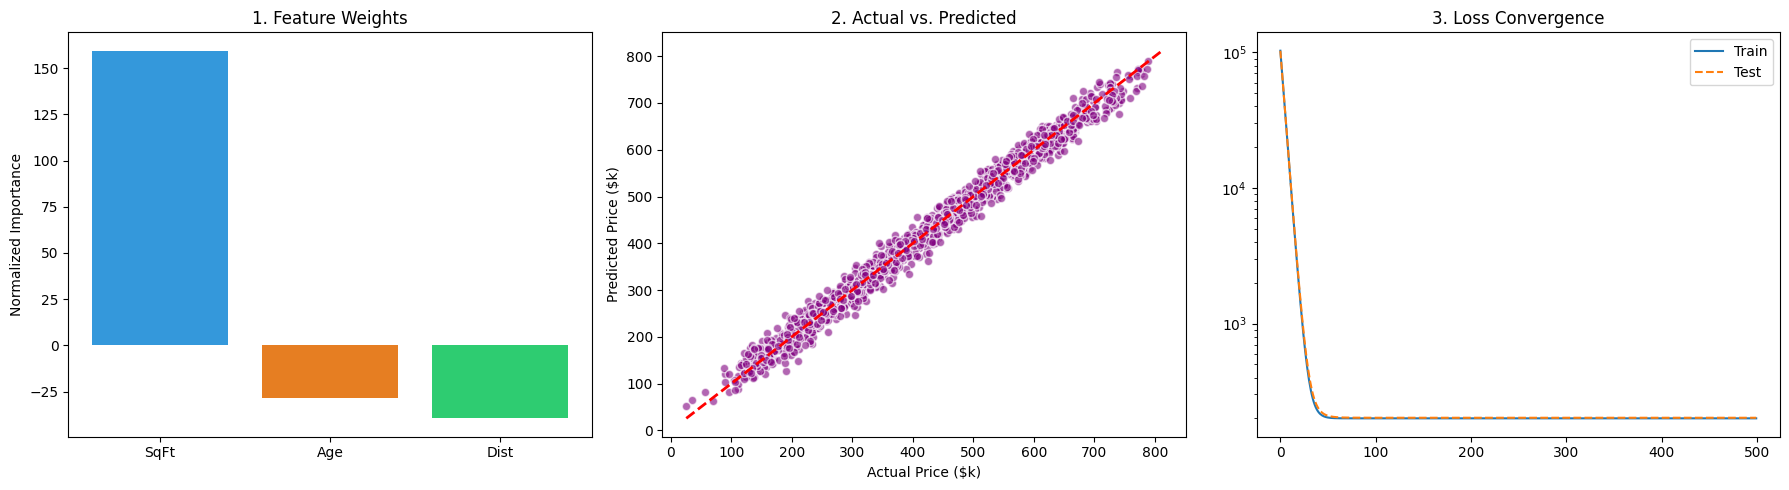

Final Bias (Intercept): 421.66
Final Train Loss: 200.1064 | Test Loss: 202.0915


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DATA GENERATION (Realistic Scales) ---
np.random.seed(42)
n_samples = 5000

# Features: Area (sqft), Age (years), Distance to Center (km)
sqft = np.random.randint(800, 4500, (n_samples, 1))
age = np.random.randint(0, 40, (n_samples, 1))
dist = np.random.uniform(1, 15, (n_samples, 1))
X_raw = np.hstack([sqft, age, dist])

# Target: Price = 0.15*sqft - 2.5*age - 10*dist + 150 + noise
y = (0.15 * sqft) - (2.5 * age) - (10 * dist) + 150 + np.random.randn(n_samples, 1) * 20

# --- 2. ALIGNED SHUFFLE & SPLIT (70/30) ---
indices = np.arange(n_samples)
np.random.shuffle(indices)

train_size = int(0.7 * n_samples)
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train_raw, y_train = X_raw[train_idx], y[train_idx]
X_test_raw, y_test = X_raw[test_idx], y[test_idx]

# --- 3. FEATURE SCALING (Crucial for Multivariate) ---
mu = np.mean(X_train_raw, axis=0)
sigma = np.std(X_train_raw, axis=0)

X_train = (X_train_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma

# --- 4. VECTORIZED GRADIENT DESCENT ---
w = np.zeros((3, 1)) # Initialize weights for 3 features
b = 0.0
lr = 0.1
epochs = 500
n_tr = float(len(X_train))

train_loss, test_loss = [], []

for i in range(epochs):
    # Predictions
    y_tr_pred = X_train @ w + b
    y_ts_pred = X_test @ w + b

    # Quadratic Cost (MSE)
    train_loss.append(np.mean((y_tr_pred - y_train)**2) / 2)
    test_loss.append(np.mean((y_ts_pred - y_test)**2) / 2)

    # Vectorized Gradient
    err = y_tr_pred - y_train
    dw = (1/n_tr) * (X_train.T @ err)
    db = np.mean(err)

    # Update
    w -= lr * dw
    b -= lr * db

# --- 5. VISUALIZATION (Fixed for Matplotlib Shapes) ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Feature Weights
axs[0].bar(['SqFt', 'Age', 'Dist'], w.flatten(), color=['#3498db', '#e67e22', '#2ecc71'])
axs[0].set_title("1. Feature Weights")
axs[0].set_ylabel("Normalized Importance")

# Plot 2: Correlation (FORCED FLATTEN TO PREVENT VALUEERROR)
# Using .flatten() ensures both X and Y are simple 1D arrays of the same size
axs[1].scatter(y_test.flatten(), y_ts_pred.flatten(), alpha=0.6, edgecolors='w', color='purple')
axs[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axs[1].set_xlabel("Actual Price ($k)")
axs[1].set_ylabel("Predicted Price ($k)")
axs[1].set_title("2. Actual vs. Predicted")

# Plot 3: Convergence
axs[2].plot(train_loss, label='Train')
axs[2].plot(test_loss, '--', label='Test')
axs[2].set_title("3. Loss Convergence")
axs[2].set_yscale('log')
axs[2].legend()

plt.tight_layout()
plt.show()

print(f"Final Bias (Intercept): {b:.2f}")
print(f"Final Train Loss: {train_loss[-1]:.4f} | Test Loss: {test_loss[-1]:.4f}")

### **Standardization:**

what happens to the weights if they skip the "Feature Scaling" step. (The model will likely fail to converge or require a much smaller learning rate).

### **Weight Direction:**

Note that Age and Distance have negative weights. This confirms the intuitive logic that as a house gets older or further from the center, its price decreases.